## 倍音構成を読み取って時間方向に平均化したものを特徴量とした場合
・PCAを行い分析した結果、まったく分類できなかった。

Vector shape: (64,)
First 5 harmonics (dB): [38.09503813 31.9404977  28.6764223  26.04184931 23.95614896]


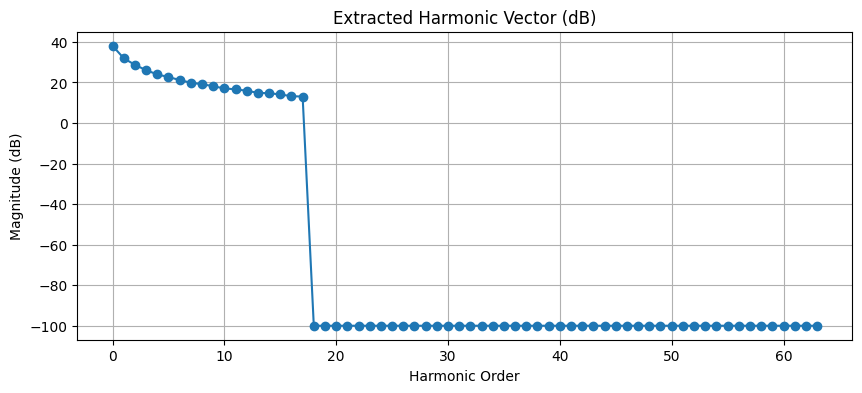

In [5]:
import numpy as np
import librosa
import warnings
import matplotlib.pyplot as plt

def extract_harmonic_magnitudes(y, sr=16000, n_fft=2048, hop_length=64, n_harmonics=60, f0_input=None):
  """
  スペクトログラムからf0に追従して倍音成分を抜き出し、時間平均したスペクトルを返す。
  Returns:
      harmonic_vector(np.array): [n_harmonics]の形状を持つ静的な倍音ベクトル（dB単位）
  """

  # 0. STFTの計算
  S = np.abs(librosa.stft(y, n_fft=n_fft, hop_length=hop_length))
  n_freq_bins, n_frames = S.shape
  freqs = librosa.fft_frequencies(sr=sr, n_fft=n_fft)

  # 1. 基本周波数 (f0) の推定
  # 既にf0を持っている場合はそれを使う (計算短縮)
  if f0_input is None:
      # PYINなどで推定 (少し重いです)
      f0, _, _ = librosa.pyin(y, fmin=librosa.note_to_hz('C1'), fmax=librosa.note_to_hz('C7'), sr=sr, frame_length=n_fft, hop_length=hop_length)
      # f0の長さがSと合わないことがあるので調整
      if len(f0) < n_frames:
          f0 = np.pad(f0, (0, n_frames - len(f0)), constant_values=np.nan)
      else:
          f0 = f0[:n_frames]



  # 2. 倍音抽出用のコンテナ
  # 初期値をNaNにしておくことで存在しない倍音を平均計算から除外する
  harmonic_matrix = np.full((n_harmonics, n_frames), np.nan)

  # 3. フレームごとの抽出処理
  for t in range(n_frames): # ある時刻tにおける処理
    current_f0 = f0[t]

    # f0が推定できていないフレームはスキップ
    if np.isnan(current_f0):
      continue

    # ナイキスト周波数（sr/2）
    nyquist_freq = sr / 2

    # 各倍音について処理
    for k in range(1, n_harmonics + 1):
      target_freq = current_f0 * k

      # ナイキスト周波数を超えたら、それ以上の倍音は存在しない->break
      if target_freq > nyquist_freq:
        break

      # 周波数をビン番号に変換
      target_bin_float = target_freq * n_fft / sr
      center_bin = int(np.round(target_bin_float))

      # 範囲外に値を入れない
      if center_bin >= n_freq_bins:
        break

      # ---local peak picking ---
      # 計算上のビンの周辺（±1ビン）を見て、最大値を採用する
      # これによりf0の微細なずれを吸収する（一方で、今回1ビンあたりの周波数は43Hz程度であり、コントラバスの最低音は40Hz程度なので、倍音を下手に拾ってしまう可能性が有り得る。窓幅の再設定が必要）
      b_min = max(0, center_bin - 1)
      b_max = min(n_freq_bins, center_bin + 2)

      local_max_amp = np.max(S[b_min:b_max, t])
      harmonic_matrix[k-1, t] = local_max_amp

    # 5. 時間方向の集約 (修正箇所)
    # Python標準のwarningsを使って警告を抑制
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        # 全てNaNの列があっても警告を出さずに計算
        harmonic_vector_linear = np.nanmean(harmonic_matrix, axis=1)

    # 一度も出現しなかった倍音(NaN)は 0.0 (微小値) に置換
    harmonic_vector_linear = np.nan_to_num(harmonic_vector_linear, nan=1e-9)
    # 対数変換。PCAにかけるなら人間の聴覚に近いスケールの方が線形分離しやすい
    harmonic_vector = librosa.amplitude_to_db(harmonic_vector_linear, top_db = None)

    return harmonic_vector


# --- 実行例 ---
# ダミーデータ生成 (ノコギリ波: 全倍音を含む)
sr = 16000
duration = 2.0
t = np.linspace(0, duration, int(sr * duration))
f0_dummy = 440.0 # A4
y = 0.5 * (2 * (t * f0_dummy % 1) - 1) # Sawtooth wave

# 抽出実行
vector = extract_harmonic_magnitudes(y, sr=sr, n_harmonics=64)

# 結果表示
print(f"Vector shape: {vector.shape}") # (64,)
print(f"First 5 harmonics (dB): {vector[:5]}")

plt.figure(figsize=(10, 4))
plt.plot(vector, marker='o')
plt.title("Extracted Harmonic Vector (dB)")
plt.xlabel("Harmonic Order")
plt.ylabel("Magnitude (dB)")
plt.grid(True)
plt.show()

Found 968 files in /content/drive/MyDrive/hioki_lab/data/URMP_solo_inst/processed_data
Extracting harmonic features...


100%|██████████| 968/968 [06:36<00:00,  2.44it/s]


Explained Variance Ratio: [0.80118311 0.10252704]
PC1: 80.12%
PC2: 10.25%


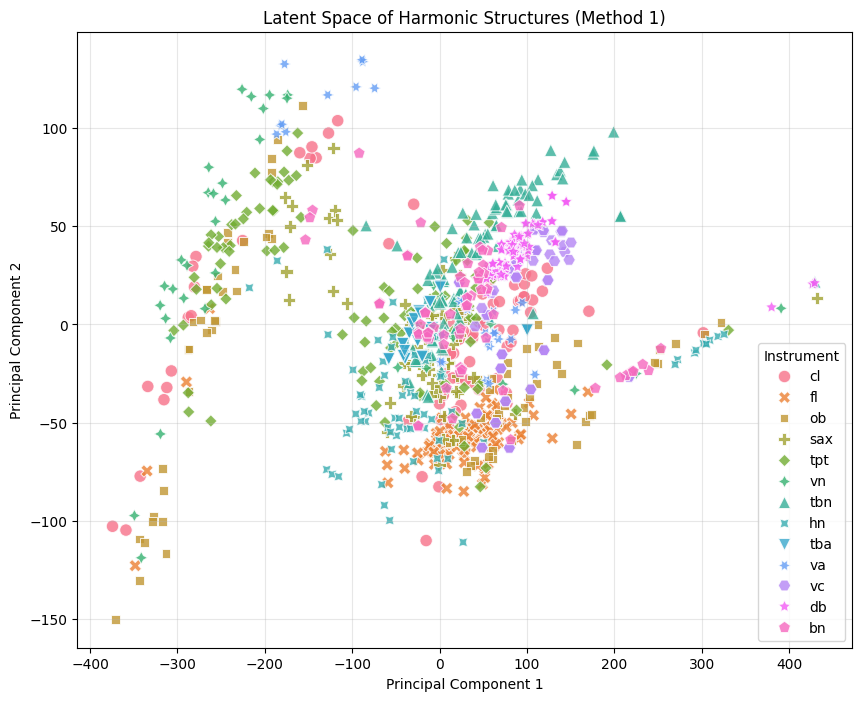

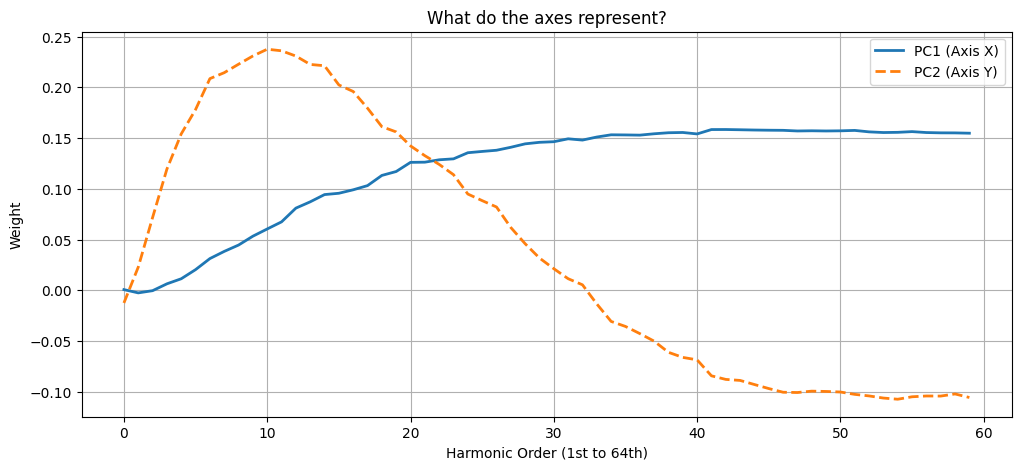

In [5]:
import torch
import numpy as np
import librosa
import glob
import os
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings

# ==========================================
# 1. 倍音抽出関数 (Method 1: f0追従型)
# ==========================================
def extract_harmonic_vector_from_pt(audio, f0, sr=16000, n_fft=2048, hop_length=64, n_harmonics=60):
    """
    .ptファイル内のaudioとf0を使って倍音ベクトルを計算する
    """
    # STFT計算
    # audioはTensorの可能性があるのでnumpy化
    if isinstance(audio, torch.Tensor):
        y = audio.numpy()
    else:
        y = audio

    S = np.abs(librosa.stft(y, n_fft=n_fft, hop_length=hop_length))
    n_freq_bins, n_frames = S.shape

    # f0の調整 (Tensor -> numpy)
    if isinstance(f0, torch.Tensor):
        f0_seq = f0.squeeze().numpy()
    else:
        f0_seq = f0.squeeze()

    # f0とSTFTのフレーム数が合わない場合の安全策 (minをとる)
    n_process = min(len(f0_seq), n_frames)

    harmonic_matrix = np.full((n_harmonics, n_process), np.nan)
    nyquist = sr / 2.0

    for t in range(n_process):
        current_f0 = f0_seq[t]

        # 無音・非有声判定 (CREPEの出力によっては0やnanになる)
        if np.isnan(current_f0) or current_f0 <= 40:
            continue

        for k in range(1, n_harmonics + 1):
            target_freq = k * current_f0

            if target_freq >= nyquist:
                break

            # ビン番号計算
            target_bin_float = target_freq * n_fft / sr
            center_bin = int(np.round(target_bin_float))

            if center_bin >= n_freq_bins:
                break

            # Local Peak Picking
            b_min = max(0, center_bin - 1)
            b_max = min(n_freq_bins, center_bin + 2)

            local_max_amp = np.max(S[b_min:b_max, t])
            harmonic_matrix[k-1, t] = local_max_amp

    # 時間平均 (Temporal Pooling)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        harmonic_vector_linear = np.nanmean(harmonic_matrix, axis=1)

    # NaN埋め
    harmonic_vector_linear = np.nan_to_num(harmonic_vector_linear, nan=1e-9)

    # dB変換
    harmonic_vector_db = librosa.amplitude_to_db(harmonic_vector_linear, top_db=None)

    # 正規化 (Shapeだけを見たいので、最大値を0dBに揃える)
    # これをやらないと「音量のデカい音」が別クラスに分類されてしまう
    harmonic_vector_norm = harmonic_vector_db - np.max(harmonic_vector_db)

    return harmonic_vector_norm

# ==========================================
# 2. データセット読み込み & 解析プロセス
# ==========================================
def analyze_dataset_pca(pt_dir, sr=16000, n_fft=2048, hop_length=64):

    # .ptファイルを検索
    pt_files = glob.glob(os.path.join(pt_dir, "*.pt"))
    print(f"Found {len(pt_files)} files in {pt_dir}")

    features = []
    labels = []

    print("Extracting harmonic features...")
    for pt_path in tqdm(pt_files):
        try:
            # Load Data
            data = torch.load(pt_path)

            # 必要なデータを取り出す
            audio = data['audio'] # [Time]
            f0 = data['f0']       # [Time, 1]
            instrument_name = data['instrument_name']

            # 倍音ベクトル抽出 (Method 1)
            # ここで前処理時と同じhop_lengthを指定することが重要！
            vec = extract_harmonic_vector_from_pt(audio, f0, sr=sr, n_fft=n_fft, hop_length=hop_length)

            features.append(vec)
            labels.append(instrument_name)

        except Exception as e:
            print(f"Error loading {pt_path}: {e}")
            continue

    return np.array(features), np.array(labels)

# ==========================================
# 3. PCA実行と可視化
# ==========================================
def run_pca_visualization(X, y):
    if len(X) == 0:
        print("No features to analyze.")
        return

    # PCA
    pca = PCA(n_components=2)
    latent_z = pca.fit_transform(X)

    print(f"Explained Variance Ratio: {pca.explained_variance_ratio_}")
    print(f"PC1: {pca.explained_variance_ratio_[0]:.2%}")
    print(f"PC2: {pca.explained_variance_ratio_[1]:.2%}")

    # Plot 1: 散布図 (潜在空間)
    plt.figure(figsize=(10, 8))
    sns.scatterplot(x=latent_z[:, 0], y=latent_z[:, 1], hue=y, style=y, s=80, alpha=0.8)
    plt.title("Latent Space of Harmonic Structures (Method 1)")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.grid(True, alpha=0.3)
    plt.legend(title='Instrument')
    plt.show()

    # Plot 2: 固有ベクトルの意味 (ローディング)
    plt.figure(figsize=(12, 5))
    plt.plot(pca.components_[0], label='PC1 (Axis X)', linewidth=2)
    plt.plot(pca.components_[1], label='PC2 (Axis Y)', linewidth=2, linestyle='--')
    plt.title("What do the axes represent?")
    plt.xlabel("Harmonic Order (1st to 64th)")
    plt.ylabel("Weight")
    plt.legend()
    plt.grid(True)
    plt.show()

# ==========================================
# 実行ブロック
# ==========================================
# 前処理の設定に合わせて変更してください
SR = 16000
N_FFT = 2048
HOP_LENGTH = 64  # extract_featuresで指定した値と合わせてください！
OUTPUT_DIR = "/content/drive/MyDrive/hioki_lab/data/URMP_solo_inst/processed_data" # .ptファイルがある場所

# 1. 解析実行
X, y = analyze_dataset_pca(OUTPUT_DIR, sr=SR, n_fft=N_FFT, hop_length=HOP_LENGTH)

# 2. 可視化
run_pca_visualization(X, y)

Dataset Shape: (968, 60)

[Metric 1] Silhouette Score (Original Space): -0.1656
  -> (目安: 0.5以上=良, 0.2周辺=重なりあり, 0以下=失敗)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



[Metric 2] Linear Classification Accuracy: 57.22%
  -> (もし低いなら、倍音抽出自体がうまくいっていない)


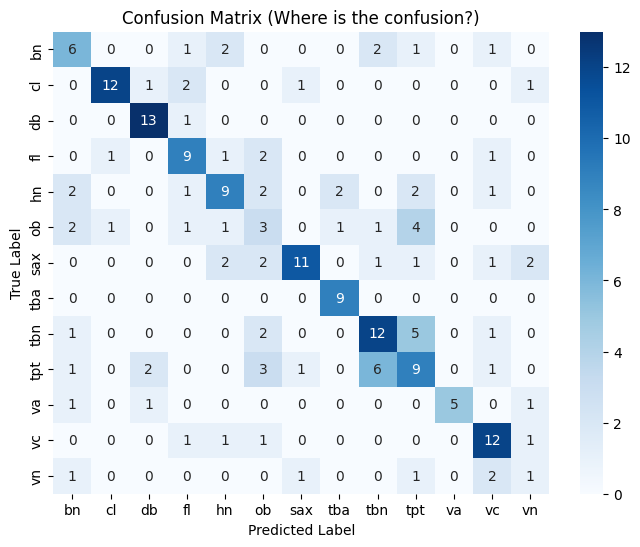

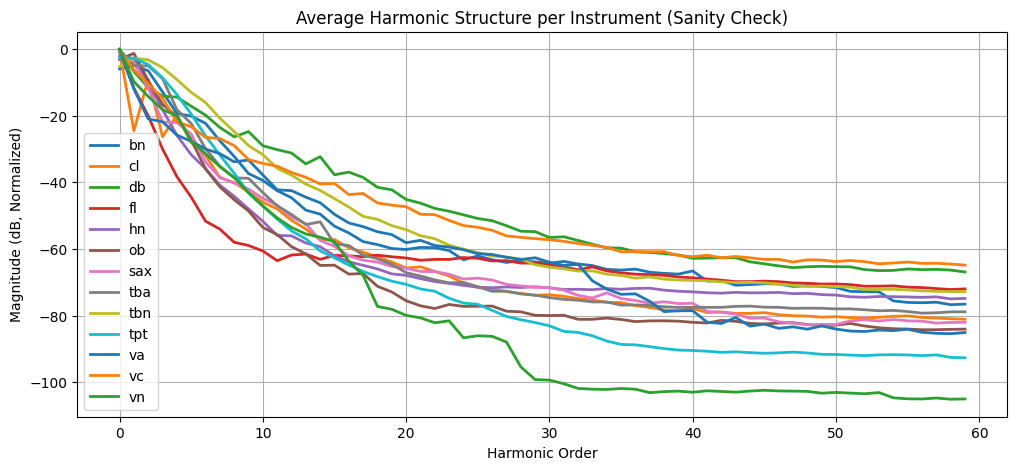

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score, accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def evaluate_features(X, y):
    """
    抽出された特徴量(X)とラベル(y)の品質を評価する
    """
    print(f"Dataset Shape: {X.shape}")

    # --- 1. シルエット係数 (PCA空間ではなく、元の64次元空間で測る) ---
    # データが多いと重いので、最大1000サンプルで計算
    if len(X) > 1000:
        idx = np.random.choice(len(X), 1000, replace=False)
        X_sub, y_sub = X[idx], y[idx]
    else:
        X_sub, y_sub = X, y

    sil_score = silhouette_score(X_sub, y_sub)
    print(f"\n[Metric 1] Silhouette Score (Original Space): {sil_score:.4f}")
    print("  -> (目安: 0.5以上=良, 0.2周辺=重なりあり, 0以下=失敗)")

    # --- 2. 線形分類精度 (Logistic Regression) ---
    # データを分割
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # 簡易学習
    clf = LogisticRegression(max_iter=1000, multi_class='auto')
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print(f"\n[Metric 2] Linear Classification Accuracy: {acc:.2%}")
    print("  -> (もし低いなら、倍音抽出自体がうまくいっていない)")

    # 混同行列 (どの楽器とどの楽器が間違えられているか)
    cm = confusion_matrix(y_test, y_pred, labels=np.unique(y))
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=np.unique(y), yticklabels=np.unique(y), cmap='Blues')
    plt.title("Confusion Matrix (Where is the confusion?)")
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

    # --- 3. 「平均倍音ベクトル」の可視化 (最重要デバッグ) ---
    # 楽器ごとの「平均的な64次元ベクトル」を描画する。
    # もしこれが全部同じ形に見えるなら、抽出処理にバグがある。

    unique_labels = np.unique(y)
    plt.figure(figsize=(12, 5))

    for label in unique_labels:
        # その楽器のデータだけを取り出す
        indices = np.where(y == label)[0]
        vectors = X[indices]

        # 平均ベクトル
        mean_vector = np.mean(vectors, axis=0)
        plt.plot(mean_vector, label=label, linewidth=2)

    plt.title("Average Harmonic Structure per Instrument (Sanity Check)")
    plt.xlabel("Harmonic Order")
    plt.ylabel("Magnitude (dB, Normalized)")
    plt.legend()
    plt.grid(True)
    plt.show()

# --- 実行 ---
# X, y は前回の analyze_dataset_pca で取得したものを使ってください
evaluate_features(X, y)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')